In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

In [2]:
# 1. Load area data
df_area = pd.read_excel('Lake_area.xlsx') 
df_area.rename(columns={'datatime': 'year', 'area': 'area_km2'}, inplace=True)
print("原始面积数据：")
print(df_area)

# 线性插值补全2012年面积
if 2012 not in df_area['year'].values:
    area_2011 = df_area[df_area['year']==2011]['area_km2'].values[0]
    area_2013 = df_area[df_area['year']==2013]['area_km2'].values[0]
    area_2012 = (area_2011 + area_2013) / 2
    new_row = pd.DataFrame({'year': [2012], 'area_km2': [area_2012]})
    df_area = pd.concat([df_area, new_row], ignore_index=True)
    df_area = df_area.sort_values('year').reset_index(drop=True)
    print(f"插值得到2012年面积: {area_2012:.2f} km²")
else:
    if pd.isnull(df_area[df_area['year']==2012]['area_km2'].values[0]):
        df_area = df_area.set_index('year').interpolate(method='linear').reset_index()
        print("线性插值补全2012年面积")

print("\n补全后的面积数据：")
print(df_area)

原始面积数据：
    year  area_km2
0   2000   4295.72
1   2001   4268.03
2   2002   4274.62
3   2003   4259.72
4   2004   4254.91
5   2005   4287.10
6   2006   4297.91
7   2007   4300.50
8   2008   4298.23
9   2009   4306.01
10  2010   4332.28
11  2011   4361.00
12  2013   4403.67
13  2014   4395.97
14  2015   4409.13
15  2016   4447.93
16  2017   4478.72
17  2018   4529.88
18  2019   4562.78
19  2020   4596.64
20  2021   4592.81
21  2022   4594.57
22  2023   4595.05
23  2024   4634.61
24  2025   4634.35
插值得到2012年面积: 4382.34 km²

补全后的面积数据：
    year  area_km2
0   2000  4295.720
1   2001  4268.030
2   2002  4274.620
3   2003  4259.720
4   2004  4254.910
5   2005  4287.100
6   2006  4297.910
7   2007  4300.500
8   2008  4298.230
9   2009  4306.010
10  2010  4332.280
11  2011  4361.000
12  2012  4382.335
13  2013  4403.670
14  2014  4395.970
15  2015  4409.130
16  2016  4447.930
17  2017  4478.720
18  2018  4529.880
19  2019  4562.780
20  2020  4596.640
21  2021  4592.810
22  2022  4594.570
23  20

In [3]:
# 2. Read water level data and calculate the average from 7-10
df_water = pd.read_excel('water_level.xlsx')
# 列名: 'datatime', 'wse', 'wse_u' 
print("\n原始水位数据前5行：")
print(df_water.head())

df_water['datatime'] = pd.to_datetime(df_water['datatime'])
df_water['year'] = df_water['datatime'].dt.year
df_water['month'] = df_water['datatime'].dt.month

df_summer = df_water[df_water['month'].isin([7,8,9,10])].copy()
print(f"\n7-10月共有 {len(df_summer)} 条记录")

df_level_avg = df_summer.groupby('year')['wse'].mean().reset_index()
df_level_avg.rename(columns={'wse': 'level_avg'}, inplace=True)
print("\n每年7-10月平均水位：")
print(df_level_avg)


原始水位数据前5行：
             datatime       wse  wse_u
0 2002-07-04 14:53:03  3192.925  0.000
1 2002-08-11 03:44:05  3193.087  0.003
2 2002-09-12 14:53:01  3193.053  0.000
3 2002-09-15 03:44:04  3193.180  0.002
4 2002-10-17 14:53:03  3193.079  0.003

7-10月共有 157 条记录

每年7-10月平均水位：
    year    level_avg
0   2002  3193.063667
1   2003  3192.953500
2   2004  3192.873125
3   2005  3193.221500
4   2006  3193.322875
5   2007  3193.399333
6   2008  3193.400286
7   2009  3193.448875
8   2010  3193.767000
9   2013  3194.460250
10  2014  3194.464429
11  2015  3194.646429
12  2016  3194.689500
13  2017  3195.152889
14  2018  3195.730444
15  2019  3196.223300
16  2020  3196.610875
17  2021  3196.692600
18  2022  3196.714625
19  2023  3196.747500
20  2024  3196.888000


In [ ]:
# 3. Combined area and water level
df_merged = pd.merge(df_area, df_level_avg, on='year', how='left')
df_merged = df_merged.sort_values('year').reset_index(drop=True)

print("\n合并后数据（含缺失水位）：")
print(df_merged)

# 对缺失的水位进行简单插值（如果缺失年份不多，建议直接删除，否则梯形法会失效）
# 这里为了后续蓄水量计算连续，对水位进行线性插值（注意仅插值中间缺失，首尾不插）
df_merged['level_avg'] = df_merged['level_avg'].interpolate(method='linear', limit_direction='both')
print("\n水位插值后：")
print(df_merged)


合并后数据（含缺失水位）：
    year  area_km2    level_avg
0   2000  4295.720          NaN
1   2001  4268.030          NaN
2   2002  4274.620  3193.063667
3   2003  4259.720  3192.953500
4   2004  4254.910  3192.873125
5   2005  4287.100  3193.221500
6   2006  4297.910  3193.322875
7   2007  4300.500  3193.399333
8   2008  4298.230  3193.400286
9   2009  4306.010  3193.448875
10  2010  4332.280  3193.767000
11  2011  4361.000          NaN
12  2012  4382.335          NaN
13  2013  4403.670  3194.460250
14  2014  4395.970  3194.464429
15  2015  4409.130  3194.646429
16  2016  4447.930  3194.689500
17  2017  4478.720  3195.152889
18  2018  4529.880  3195.730444
19  2019  4562.780  3196.223300
20  2020  4596.640  3196.610875
21  2021  4592.810  3196.692600
22  2022  4594.570  3196.714625
23  2023  4595.050  3196.747500
24  2024  4634.610  3196.888000
25  2025  4634.350          NaN

水位插值后（若有必要）：
    year  area_km2    level_avg
0   2000  4295.720  3193.063667
1   2001  4268.030  3193.063667
2   2002  4

In [5]:
#  4. Trapezoidal method
# 第一年（2000年）蓄水量设为0
df_merged['V_rel'] = 0.0
for i in range(1, len(df_merged)):
    dH = df_merged.loc[i, 'level_avg'] - df_merged.loc[i-1, 'level_avg']
    avgA = (df_merged.loc[i-1, 'area_km2'] + df_merged.loc[i, 'area_km2']) / 2
    df_merged.loc[i, 'V_rel'] = df_merged.loc[i-1, 'V_rel'] + avgA * dH

print("\n最终蓄水量序列（相对值）：")
print(df_merged[['year', 'area_km2', 'level_avg', 'V_rel']])

df_merged.to_csv('qinghai_water_volume.csv', index=False)
print("\n已保存为 qinghai_water_volume.csv")




最终蓄水量序列（相对值）：
    year  area_km2    level_avg         V_rel
0   2000  4295.720  3193.063667      0.000000
1   2001  4268.030  3193.063667      0.000000
2   2002  4274.620  3193.063667      0.000000
3   2003  4259.720  3192.953500   -470.099895
4   2004  4254.910  3192.873125   -812.281588
5   2005  4287.100  3193.221500    675.629779
6   2006  4297.910  3193.322875   1110.782473
7   2007  4300.500  3193.399333   1439.492522
8   2008  4298.230  3193.400286   1443.587155
9   2009  4306.010  3193.448875   1652.624093
10  2010  4332.280  3193.767000   3026.652096
11  2011  4361.000  3193.998083   4031.088156
12  2012  4382.335  3194.229167   5041.307655
13  2013  4403.670  3194.460250   6056.457316
14  2014  4395.970  3194.464429   6074.842278
15  2015  4409.130  3194.646429   6876.106378
16  2016  4447.930  3194.689500   7066.849491
17  2017  4478.720  3195.152889   9135.104704
18  2018  4529.880  3195.730444  11736.588193
19  2019  4562.780  3196.223300  13977.272191
20  2020  4596.640 

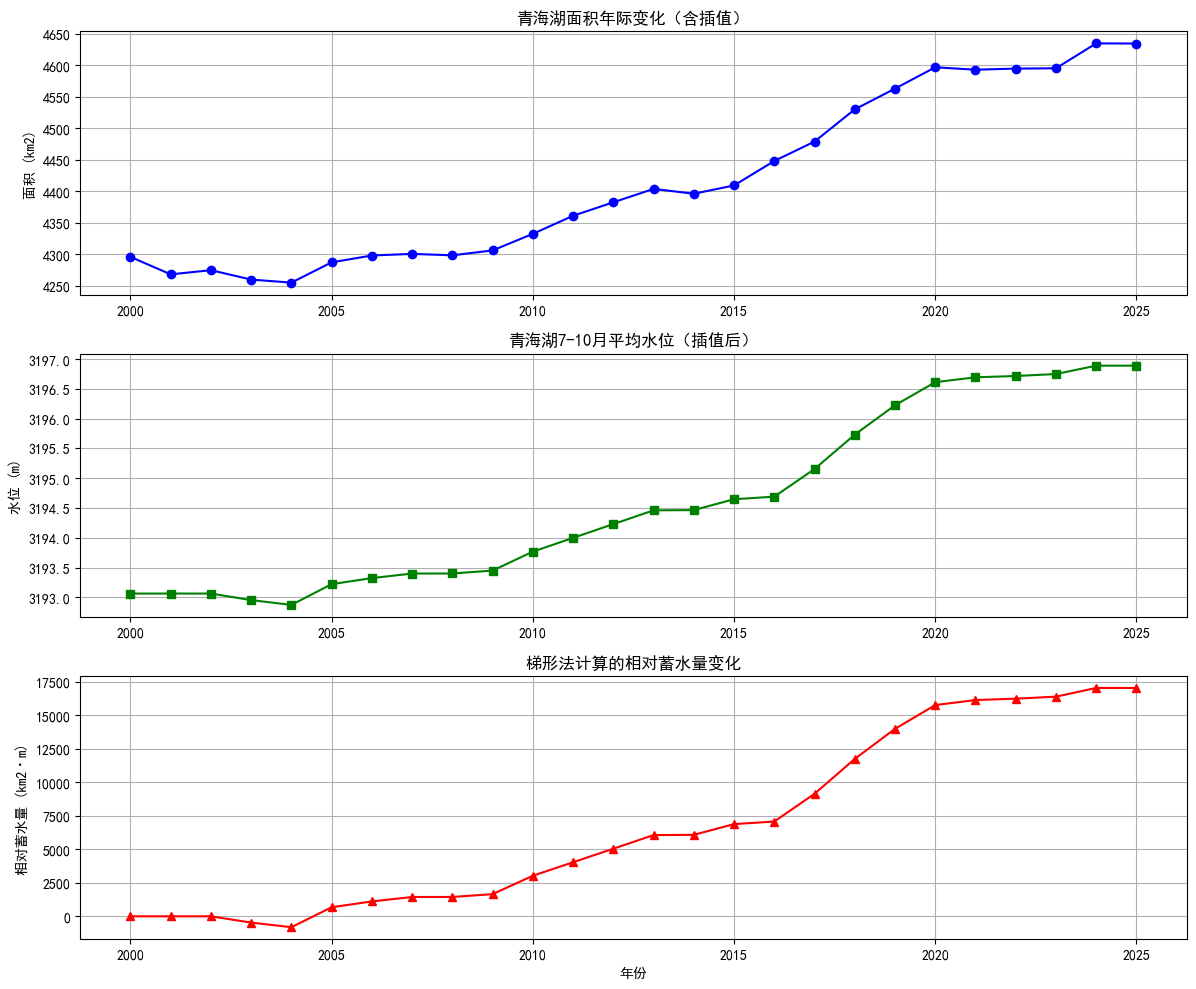

In [ ]:

# 5. Visualization
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
axes[0].plot(df_merged['year'], df_merged['area_km2'], 'o-', color='blue')
axes[0].set_ylabel('面积 (km2)')
axes[0].set_title('青海湖面积年际变化（含插值）')
axes[0].grid(True)

axes[1].plot(df_merged['year'], df_merged['level_avg'], 's-', color='green')
axes[1].set_ylabel('水位 (m)')
axes[1].set_title('青海湖7-10月平均水位（插值后）')
axes[1].grid(True)

axes[2].plot(df_merged['year'], df_merged['V_rel'], '^-', color='red')
axes[2].set_ylabel('相对蓄水量 (km2·m)')
axes[2].set_xlabel('年份')
axes[2].set_title('梯形法计算的相对蓄水量变化')
axes[2].grid(True)

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']  
plt.rcParams['axes.unicode_minus'] = False    
plt.tight_layout()
plt.savefig('蓄水量计算结果.png', dpi=300)
plt.show()